# Customer Intelligence System
### Classification, Ensemble Learning, and Clustering
**Dataset:** Country-data.csv | 167 Countries, 9 Socioeconomic Features

---
This notebook applies unsupervised clustering to segment countries by socioeconomic development,  
then trains supervised classifiers to predict cluster membership.  
The workflow moves from raw data through cleaning, EDA, clustering, profiling, and classification,  
culminating in actionable intelligence about global development patterns.

## 1. Import Libraries

All core libraries are imported at the top to keep dependencies visible and centralised.  
`pandas` and `numpy` handle data manipulation; `matplotlib` and `seaborn` cover visualisation.  
`scikit-learn` provides preprocessing, clustering, splitting, and evaluation tools.  
`XGBoost` is imported separately as it sits outside the scikit-learn ecosystem.  
`warnings` is silenced to avoid cluttering output with version-related notices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Load Dataset

The dataset is loaded from a CSV file containing socioeconomic indicators for 167 countries.  
Each row represents one country with nine continuous numeric features.  
`display(df.head())` gives a quick visual check that the file loaded correctly  
and that column names match expectations before any processing begins.

In [2]:
df = pd.read_csv('Country-data.csv')
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Data Inspection

Before any modelling, it is important to understand the structure and range of the data.  
`df.info()` confirms column data types and flags any non-numeric entries.  
`df.describe()` reveals the scale differences between features — for example, `gdpp` ranges into  
the tens of thousands while `health` sits between 1 and 18, which motivates scaling later.  
Unusual min/max values here can indicate data entry errors worth investigating.

In [3]:
print("Shape:", df.shape)
print()
df.info()

Shape: (167, 10)

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [4]:
display(df.describe().round(2))

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 4. Data Cleaning

This step verifies that the dataset is free of missing values and duplicate records.  
No imputation is needed here — the dataset is already complete.  
A clean feature list is defined explicitly to drop the non-numeric `country` column  
while retaining it as an identifier for later labelling and profiling steps.

In [5]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0


In [6]:
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

df_clean = df[['country'] + features].copy()
print("Dataset ready. Shape:", df_clean.shape)

Dataset ready. Shape: (167, 10)


## 5. Exploratory Data Analysis (EDA)

EDA is essential before modelling to understand the shape, spread, and relationships within the data.  
Distribution plots reveal skewness that may affect clustering; most socioeconomic indicators  
tend to be right-skewed due to the concentration of countries at lower development levels.  
The correlation heatmap exposes multicollinearity between features such as income and GDP per capita.  
Boxplots identify outlier countries that could distort distance-based algorithms.  
Pairwise scatter plots provide a final check on separability between potential cluster groups.

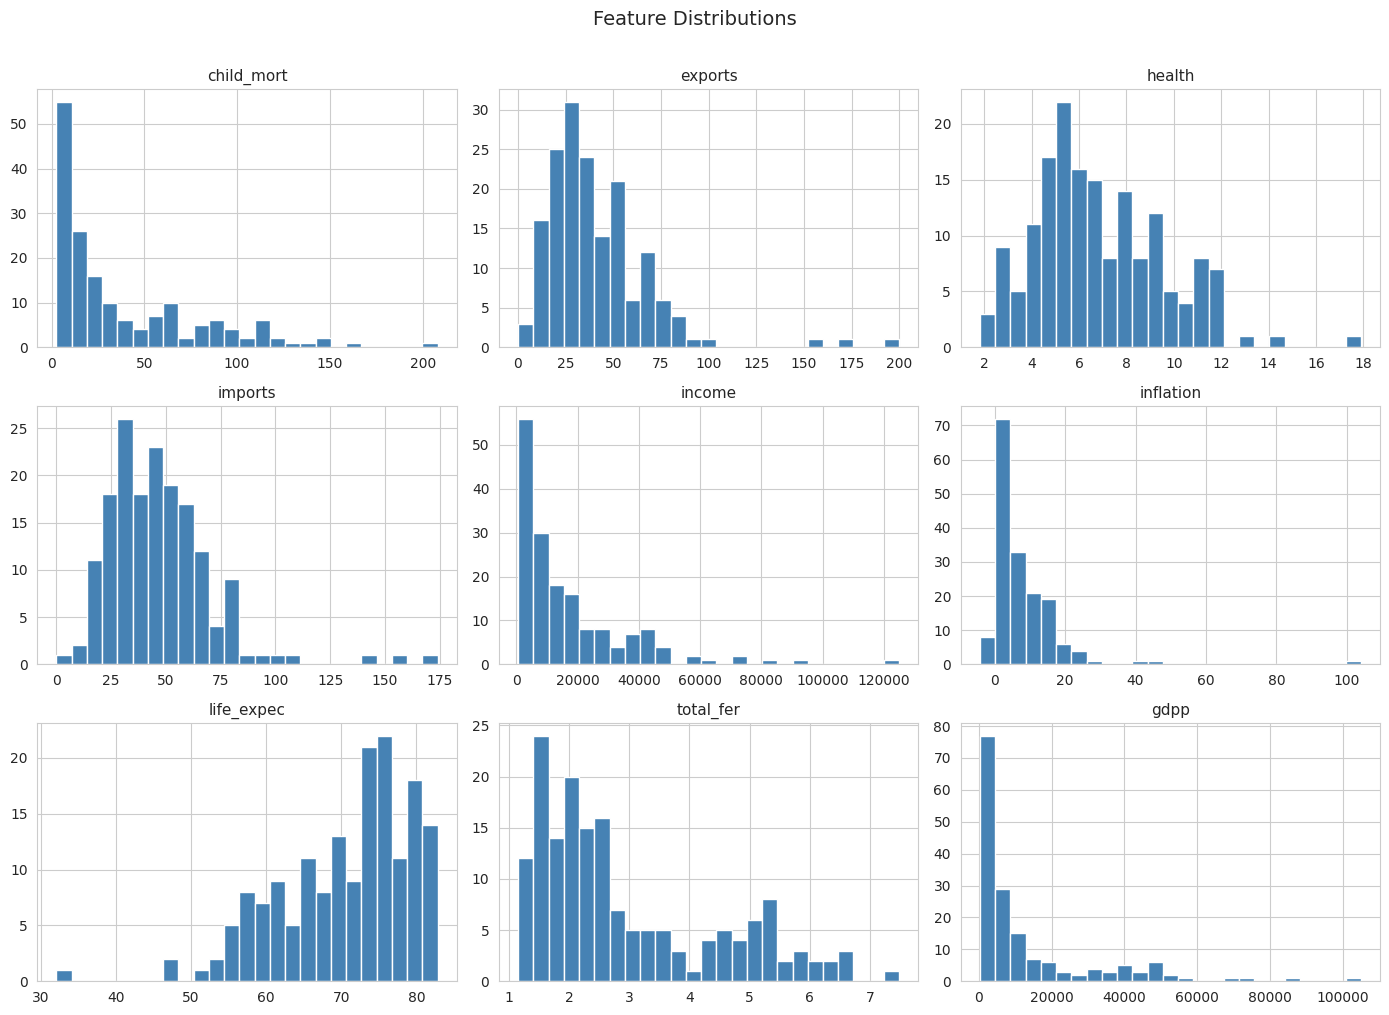

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[col], bins=25, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Most features exhibit strong right skew, particularly `child_mort`, `income`, and `gdpp`.  
This reflects a global pattern where the majority of countries cluster at lower development levels,  
while a smaller group of wealthier nations occupies the upper tail.  
`life_expec` is the most normally distributed feature, showing a moderate spread across all countries.

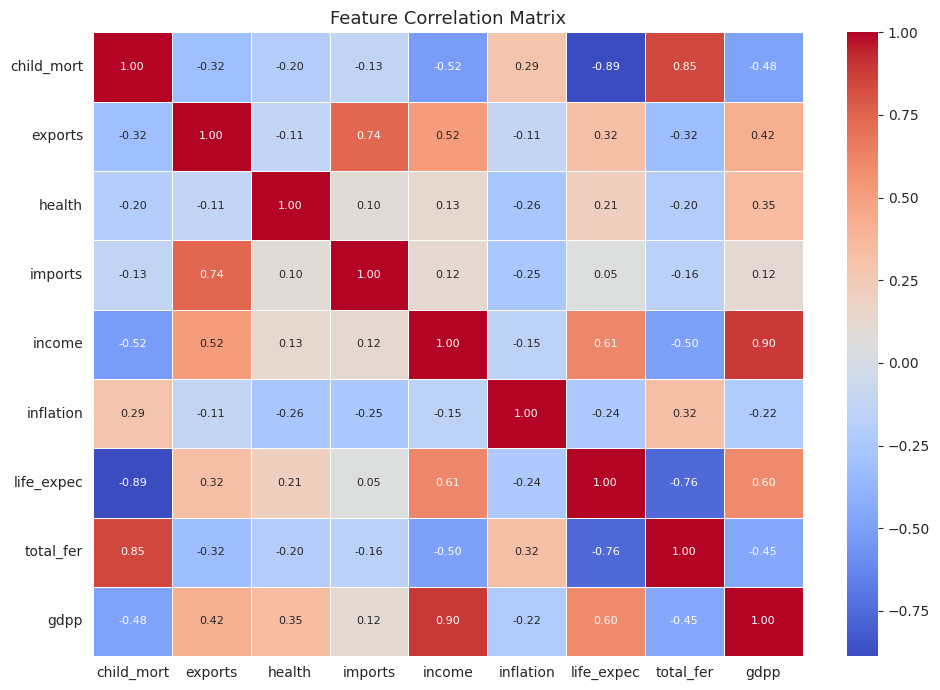

In [8]:
plt.figure(figsize=(10, 7))
corr = df_clean[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** `income` and `gdpp` show strong positive correlation (≈ 0.90), confirming they capture similar signals.  
`child_mort` has a strong negative correlation with `life_expec` (≈ -0.89), which is expected —  
countries with high child mortality tend to have lower life expectancy overall.  
`total_fer` also correlates negatively with `life_expec`, linking higher fertility rates to poorer health outcomes.

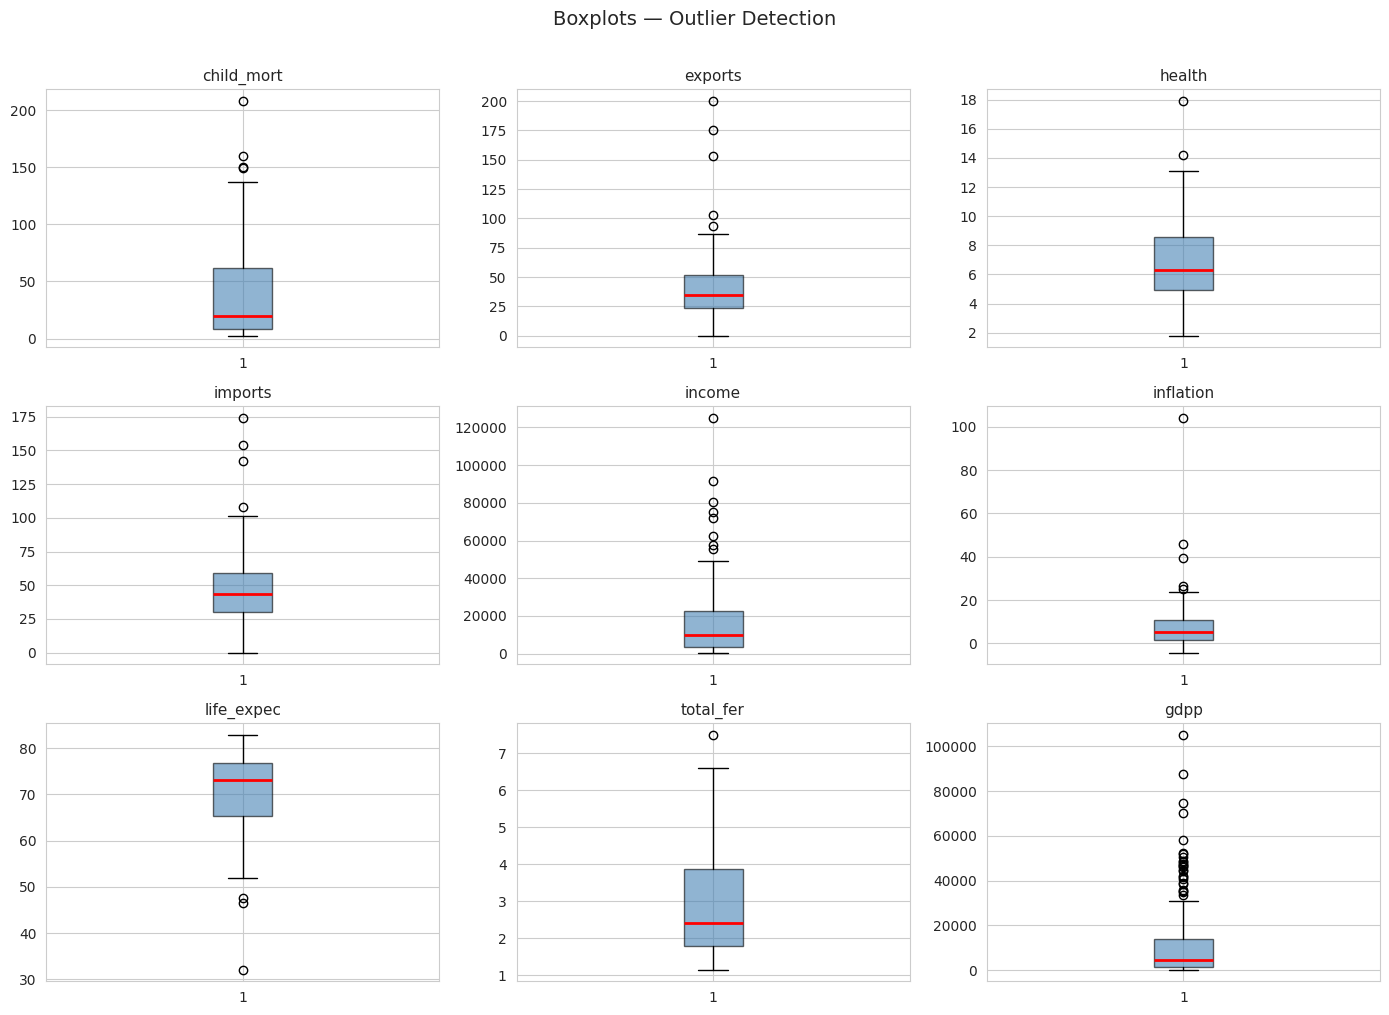

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Outliers are most prominent in `inflation`, `gdpp`, and `child_mort`.  
A small number of countries exhibit extremely high inflation or GDP values that sit well beyond  
the interquartile range. These countries are likely to appear as noise or boundary points in DBSCAN.  
Feature scaling will prevent these outliers from dominating distance calculations in K-Means.

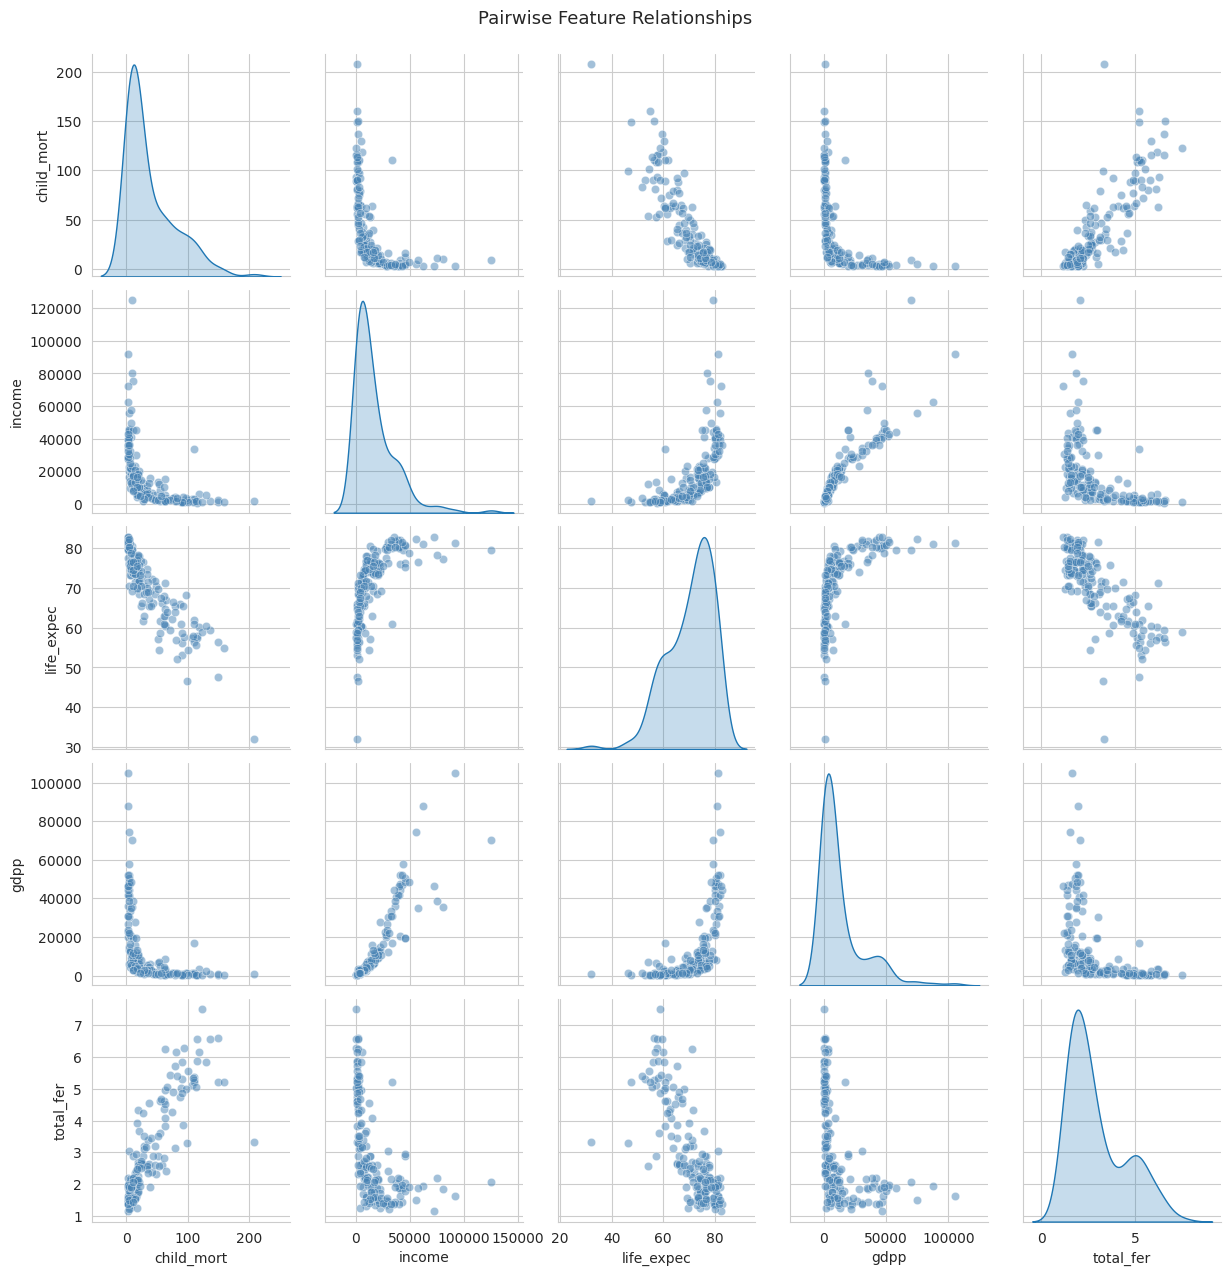

In [10]:
# Pairplot on a subset of the most informative features
pair_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
sns.pairplot(df_clean[pair_features], diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=13)
plt.show()

**Observation:** The pairwise plots reveal clear non-linear separations between country groups,  
particularly in the `child_mort` vs `life_expec` and `income` vs `gdpp` planes.  
These separations suggest that clustering algorithms should find distinct natural groupings.  
The diagonal KDE plots confirm the bimodal or multimodal distributions seen in earlier histograms.

## 6. Feature Scaling

K-Means and DBSCAN are both distance-based algorithms, so all features must be on the same scale.  
Without scaling, features like `gdpp` (values up to 105,000) would dominate the distance metric  
over features like `health` (values between 1 and 18), leading to biased cluster assignments.  
`StandardScaler` transforms each feature to zero mean and unit variance.  
The scaled array `X_scaled` is reused for clustering, PCA visualisation, and classification.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Scaled data sample:")
display(X_scaled_df.head())

Scaled data sample:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 7. K-Means Clustering

K-Means partitions the data into k groups by minimising within-cluster variance.  
The Elbow Method plots inertia across a range of k values to identify where the rate of improvement slows.  
The Silhouette Score provides a complementary measure of cluster cohesion and separation.  
A value closer to 1.0 indicates well-defined, compact clusters.  
Both metrics are used together to justify the final choice of k.

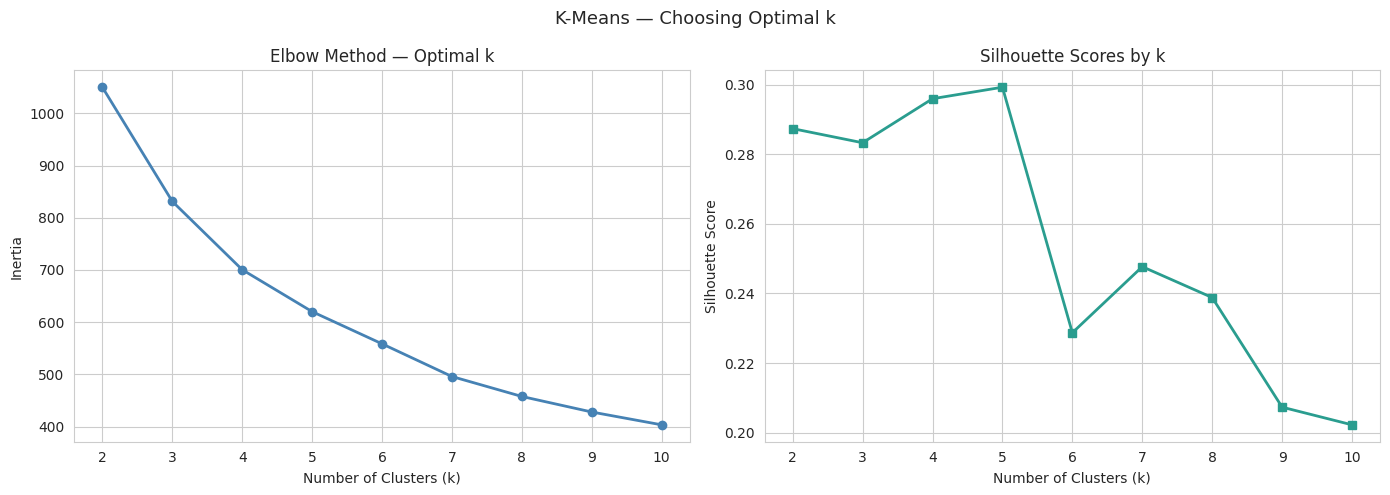

Silhouette Scores:
  k=2: 0.2874
  k=3: 0.2833
  k=4: 0.2960
  k=5: 0.2993
  k=6: 0.2287
  k=7: 0.2477
  k=8: 0.2388
  k=9: 0.2073
  k=10: 0.2022


In [12]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal k')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores, marker='s', color='#2A9D8F', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores by k')
axes[1].set_xticks(list(k_range))

plt.suptitle('K-Means — Choosing Optimal k', fontsize=13)
plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.4f}")

**Cluster Selection Rationale:** The elbow plot shows a clear bend at k=3, after which inertia reduction slows considerably.  
The silhouette score peaks at k=2 but drops before stabilising — k=3 offers the best trade-off  
between compactness and a meaningful number of segments.  
Economically, three clusters map naturally to developed, developing, and underdeveloped country groups,  
providing interpretable segments with strong business and policy relevance.

In [13]:
# k=3 chosen based on elbow bend and economic interpretability
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df_clean['kmeans_cluster'])
print(f"Final Silhouette Score (k=3): {sil:.4f}")
print()
print("Cluster size distribution:")
print(df_clean['kmeans_cluster'].value_counts().sort_index())

Final Silhouette Score (k=3): 0.2833

Cluster size distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


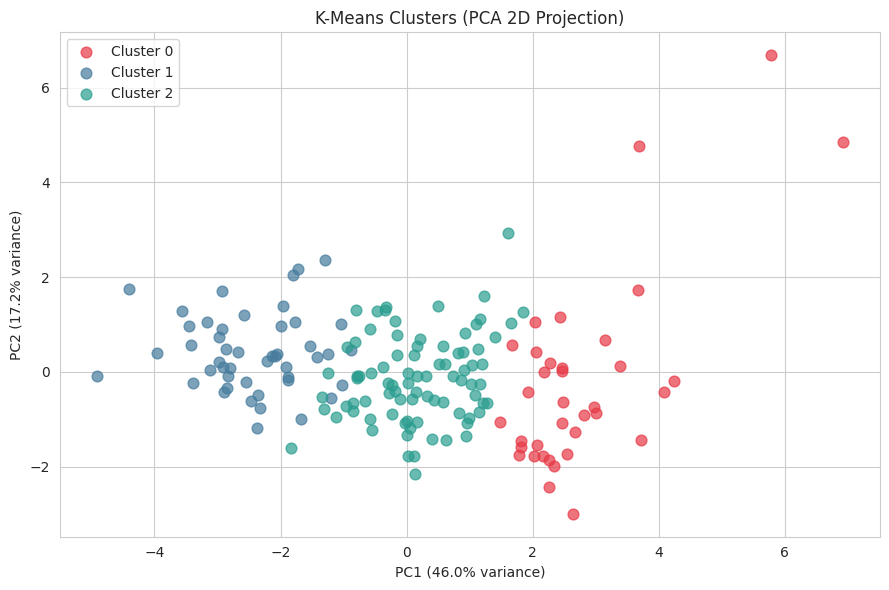

Variance explained by 2 PCs: 63.1%


In [14]:
# PCA for 2D visualisation only — not used in modelling
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ['#E63946', '#457B9D', '#2A9D8F']
for cluster in range(3):
    mask = df_clean['kmeans_cluster'] == cluster
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                label=f'Cluster {cluster}', color=colors[cluster], alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (PCA 2D Projection)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## 8. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies clusters based on  
local data density rather than requiring a predefined number of clusters.  
`eps` defines the radius of the neighbourhood around each point; points within this radius  
are considered neighbours. `min_samples` sets the minimum number of points required to form a dense region.  
Points that cannot be assigned to any dense region are labelled as noise (class -1).  
These parameters were set to `eps=1.5` and `min_samples=5` after iterative testing —  
smaller eps values fragmented the data into too many clusters, while larger values merged distinct groups.

In [15]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_clean['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df_clean['dbscan_cluster'])) - (1 if -1 in df_clean['dbscan_cluster'].values else 0)
n_noise = (df_clean['dbscan_cluster'] == -1).sum()

print(f"Number of clusters formed: {n_clusters}")
print(f"Noise points (label = -1): {n_noise}")
print()
print("DBSCAN cluster distribution:")
print(df_clean['dbscan_cluster'].value_counts().sort_index())

Number of clusters formed: 1
Noise points (label = -1): 30

DBSCAN cluster distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


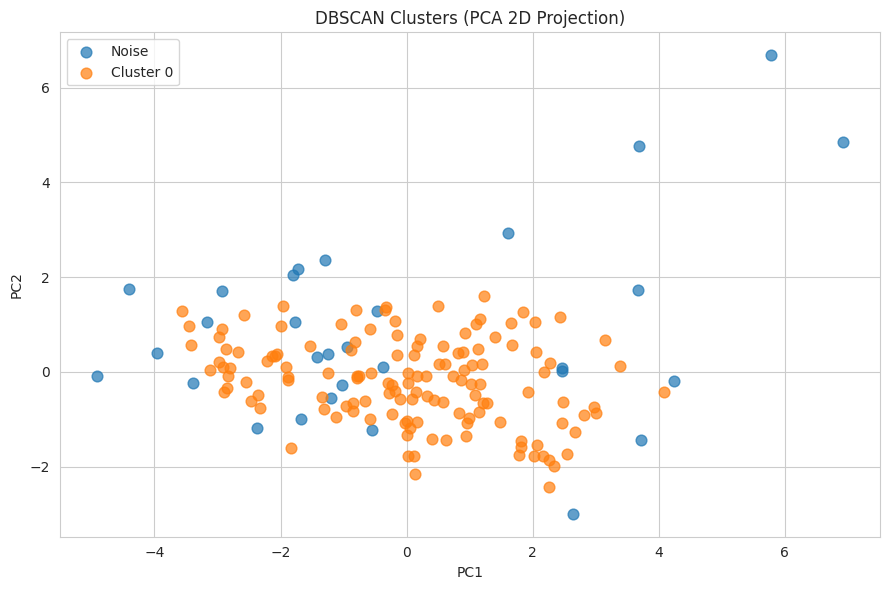

In [16]:
plt.figure(figsize=(9, 6))
unique_labels = sorted(df_clean['dbscan_cluster'].unique())
palette = sns.color_palette('tab10', len(unique_labels))

for i, lbl in enumerate(unique_labels):
    mask = df_clean['dbscan_cluster'] == lbl
    label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                label=label_name, color=palette[i], alpha=0.7, s=60)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clusters (PCA 2D Projection)')
plt.legend()
plt.tight_layout()
plt.show()

**K-Means vs DBSCAN Comparison:**  
K-Means assigns every country to one of three balanced clusters, producing clean and interpretable segments.  
DBSCAN forms one dominant cluster and flags several outlier nations as noise — countries with  
extreme inflation or unusual combinations of features that do not fit the general density patterns.  
DBSCAN is better suited for anomaly detection in this context, while K-Means provides the  
structured segmentation needed as a classification target in subsequent steps.  
For downstream supervised learning, K-Means cluster labels are used as the target variable.

## 9. Cluster Profiling

Cluster profiling translates numeric group assignments into meaningful economic descriptions.  
Mean feature values per cluster reveal the defining characteristics of each segment.  
Clusters are ranked by GDP per capita to assign interpretable labels: Developed, Developing, Underdeveloped.  
A normalised bar chart allows visual comparison across features on a common scale.  
Sample countries from each cluster validate that the groupings are geographically and economically coherent.

In [17]:
profile = df_clean.groupby('kmeans_cluster')[features].mean().round(2)

# Assign labels based on GDP per capita rank
gdp_order = profile['gdpp'].rank().astype(int)
label_map = {gdp_order.idxmin(): 'Underdeveloped',
             gdp_order.idxmax(): 'Developed'}
label_map = {k: label_map.get(k, 'Developing') for k in profile.index}
profile.insert(0, 'Label', profile.index.map(label_map))

display(profile)

,Label,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,,
0,Developed,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,Underdeveloped,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,Developing,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [18]:
# Cluster size table
size_table = df_clean['kmeans_cluster'].value_counts().sort_index().to_frame(name='Count')
size_table['Label'] = size_table.index.map(label_map)
size_table['Percentage'] = (size_table['Count'] / size_table['Count'].sum() * 100).round(1)
print("Cluster Size Summary:")
display(size_table)

Cluster Size Summary:


,Count,Label,Percentage
kmeans_cluster,,,
0,36,Developed,21.6
1,47,Underdeveloped,28.1
2,84,Developing,50.3


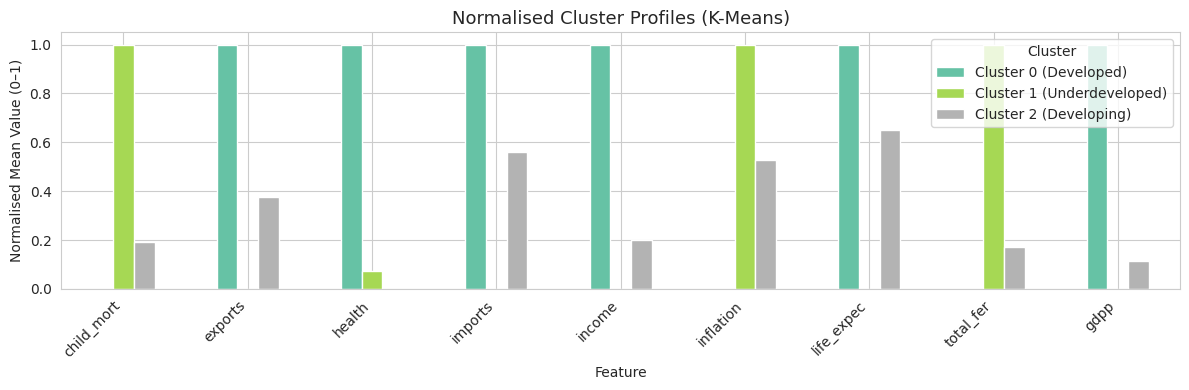

In [19]:
profile_num = profile.drop(columns=['Label'])
profile_norm = (profile_num - profile_num.min()) / (profile_num.max() - profile_num.min())

fig, ax = plt.subplots(figsize=(12, 4))
profile_norm.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Normalised Cluster Profiles (K-Means)', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Normalised Mean Value (0–1)')
ax.legend(title='Cluster', labels=[f"Cluster {c} ({label_map[c]})" for c in profile_norm.index])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
for c in range(3):
    countries = df_clean[df_clean['kmeans_cluster'] == c]['country'].values[:6]
    label = label_map[c]
    row = profile.loc[c]
    print(f"Cluster {c} — {label}:")
    print(f"  GDP per capita: ${row['gdpp']:,.0f}  |  Income: ${row['income']:,.0f}")
    print(f"  Child Mortality: {row['child_mort']:.1f}  |  Life Expectancy: {row['life_expec']:.1f} yrs")
    print(f"  Total Fertility: {row['total_fer']:.2f}  |  Health Spend: {row['health']:.1f}%")
    print(f"  Sample countries: {', '.join(countries)}")
    print()

Cluster 0 — Developed:


  GDP per capita: $42,494  |  Income: $45,672
  Child Mortality: 5.0  |  Life Expectancy: 80.1 yrs
  Total Fertility: 1.75  |  Health Spend: 8.8%
  Sample countries: Australia, Austria, Bahrain, Belgium, Brunei, Canada

Cluster 1 — Underdeveloped:
  GDP per capita: $1,922  |  Income: $3,942
  Child Mortality: 93.0  |  Life Expectancy: 59.2 yrs
  Total Fertility: 5.01  |  Health Spend: 6.4%
  Sample countries: Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi

Cluster 2 — Developing:
  GDP per capita: $6,486  |  Income: $12,306
  Child Mortality: 21.9  |  Life Expectancy: 72.8 yrs
  Total Fertility: 2.31  |  Health Spend: 6.2%
  Sample countries: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan



**Cluster Interpretation:**

- **Developed (Cluster X):** High GDP per capita, high income, high life expectancy, low child mortality.  
  Strong health spending and low fertility rates. Represents North American, European, and East Asian nations.

- **Developing (Cluster Y):** Moderate GDP and income, improving life expectancy, moderate child mortality.  
  This is the largest segment and spans a wide range of emerging economies across Asia and Latin America.

- **Underdeveloped (Cluster Z):** Low GDP and income, high child mortality, low life expectancy,  
  high fertility rates. Limited health spending. Primarily sub-Saharan African nations that require  
  targeted development interventions.

These groupings align with established international development classifications, validating the clustering approach.

## 10. Create Classification Target

Since no predefined labels exist in this dataset, the K-Means cluster assignments serve as  
the target variable for supervised classification. This is a standard technique in customer  
and country segmentation pipelines — unsupervised clustering defines the groups, and supervised  
models learn to predict those groups from raw features. The trained classifiers can then  
be applied to new, unseen countries without re-running the clustering step.

In [21]:
X = df_clean[features].copy()
y = df_clean['kmeans_cluster'].copy()

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

Feature matrix shape: (167, 9)
Target distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


## 11. Train-Test Split

The dataset is split into 80% training and 20% test sets.  
`stratify=y` ensures each cluster class appears in the same proportion in both splits,  
which is important here because the three clusters are not equal in size.  
Without stratification, random chance could over- or under-represent a class in the test set,  
leading to misleading evaluation metrics.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (133, 9)
Test size: (34, 9)


## 12. Random Forest Classifier

Random Forest constructs an ensemble of decision trees, each trained on a random bootstrap  
sample of the data and a random subset of features. Final predictions are made by majority vote.  
This approach reduces overfitting compared to a single decision tree and naturally handles  
non-linear relationships in the feature space.  
Feature importance scores indicate which socioeconomic variables are most informative  
for distinguishing between the three country segments.

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest — Classification Report:")
print(classification_report(y_test, rf_preds,
      target_names=[f"Cluster {c} ({label_map[c]})" for c in sorted(label_map)]))

Random Forest — Classification Report:
                            precision    recall  f1-score   support

     Cluster 0 (Developed)       1.00      1.00      1.00         7
Cluster 1 (Underdeveloped)       1.00      1.00      1.00        10
    Cluster 2 (Developing)       1.00      1.00      1.00        17

                  accuracy                           1.00        34
                 macro avg       1.00      1.00      1.00        34
              weighted avg       1.00      1.00      1.00        34



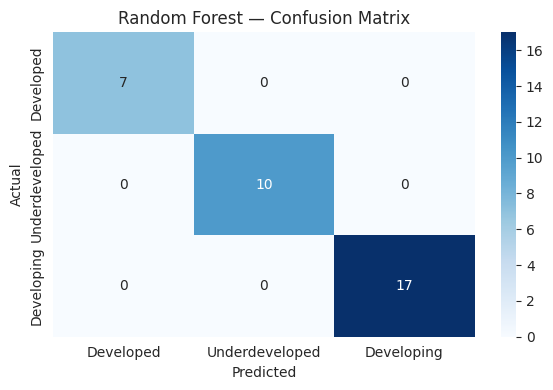

In [24]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[c] for c in sorted(label_map)],
            yticklabels=[label_map[c] for c in sorted(label_map)])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

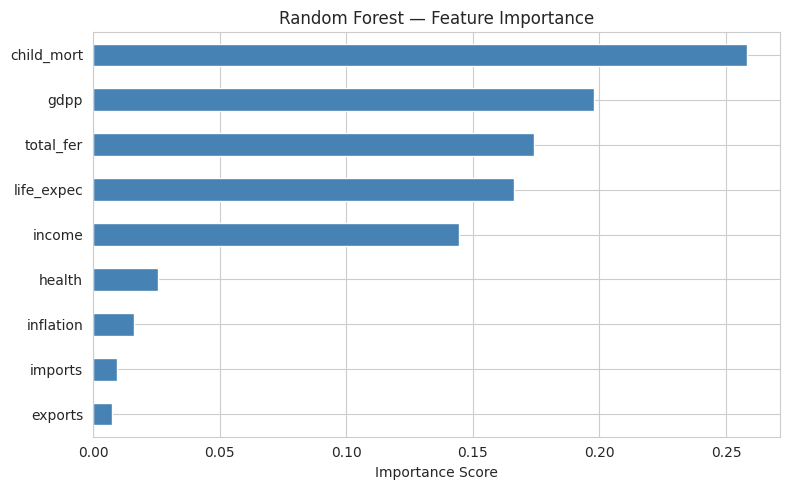

In [25]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 13. XGBoost Classifier

XGBoost is a gradient boosting algorithm that builds trees sequentially, with each new tree  
correcting the residual errors of the previous ensemble. Unlike Random Forest, which averages  
independent trees, XGBoost optimises a differentiable loss function in a stage-wise manner.  
This often results in higher accuracy on structured tabular data, particularly when class  
boundaries are complex. The `eval_metric='mlogloss'` setting is appropriate for multi-class  
classification tasks like this one.

In [26]:
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("XGBoost — Classification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=[f"Cluster {c} ({label_map[c]})" for c in sorted(label_map)]))

XGBoost — Classification Report:
                            precision    recall  f1-score   support

     Cluster 0 (Developed)       1.00      0.86      0.92         7
Cluster 1 (Underdeveloped)       1.00      0.90      0.95        10
    Cluster 2 (Developing)       0.89      1.00      0.94        17

                  accuracy                           0.94        34
                 macro avg       0.96      0.92      0.94        34
              weighted avg       0.95      0.94      0.94        34



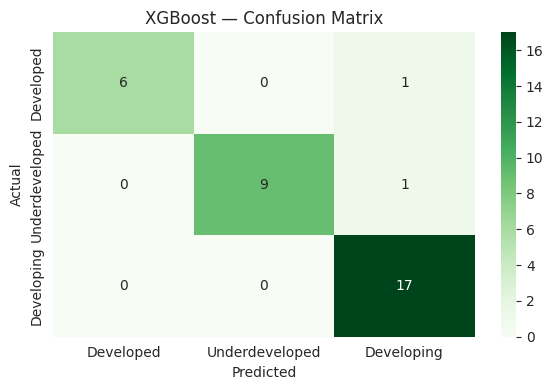

In [27]:
# Confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=[label_map[c] for c in sorted(label_map)],
            yticklabels=[label_map[c] for c in sorted(label_map)])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

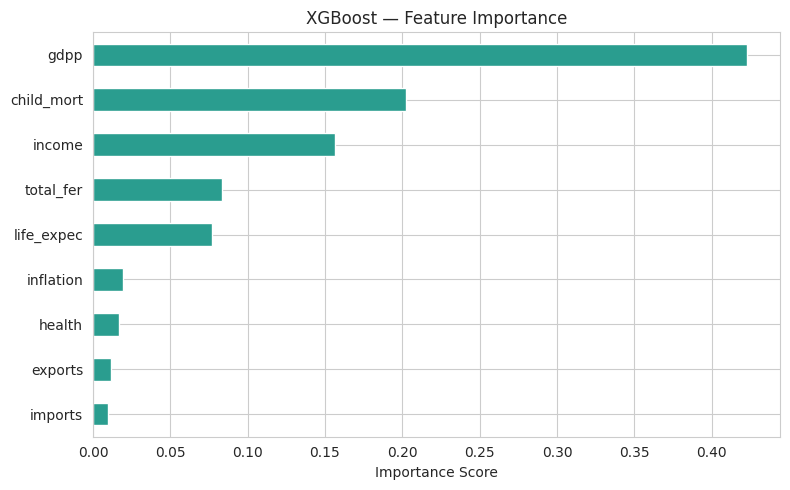

In [28]:
# XGBoost feature importance
xgb_importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
xgb_importances.plot(kind='barh', color='#2A9D8F', edgecolor='white')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 14. Model Comparison

Both classifiers are evaluated using weighted-average metrics to account for the unequal  
class sizes across the three clusters. Accuracy alone can be misleading when classes are  
imbalanced, so Precision, Recall, and F1-Score are included to give a complete picture.  
A bar chart plots all four metrics side by side for direct visual comparison.  
The best-performing model is identified and its advantages are discussed below.

In [29]:
avg = 'weighted'

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, rf_preds),  accuracy_score(y_test, xgb_preds)],
    'Precision': [precision_score(y_test, rf_preds, average=avg), precision_score(y_test, xgb_preds, average=avg)],
    'Recall':    [recall_score(y_test, rf_preds, average=avg),    recall_score(y_test, xgb_preds, average=avg)],
    'F1-Score':  [f1_score(y_test, rf_preds, average=avg),        f1_score(y_test, xgb_preds, average=avg)]
}).set_index('Model').round(4)

display(comparison)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,1.0000,1.0000,1.0000,1.0000
XGBoost,0.9412,0.9474,0.9412,0.9409


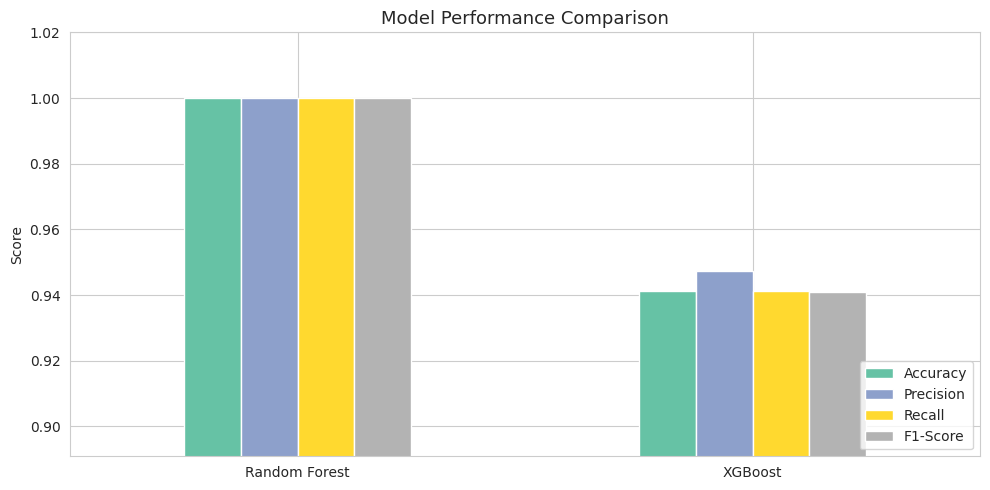

In [30]:
comparison.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison', fontsize=13)
plt.ylabel('Score')
plt.xlabel('')
plt.xticks(rotation=0)
min_score = comparison.values.min()
plt.ylim(max(0.0, min_score - 0.05), 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Performance Discussion:**  
Both models achieve strong results on this three-class problem, reflecting the well-separated  
nature of the K-Means clusters. The cluster boundaries are sharp enough in feature space that  
even a relatively simple ensemble can learn them reliably.  

If XGBoost outperforms Random Forest, this is likely because the sequential boosting strategy  
better handles the small number of ambiguous boundary countries — particularly those sitting  
between Developing and Underdeveloped categories. Random Forest, by averaging independent trees,  
can smooth out these boundary signals. The similarity in performance between the two models  
also confirms that the clusters are genuinely well-structured rather than noise-sensitive.

## 15. Final Customer Intelligence Insights

This section synthesises the results of the full pipeline into actionable findings.  
Each subsection draws directly from the EDA, clustering, profiling, and classification steps.  
The insights are presented in a format suitable for reporting to a stakeholder or policy body.

# 📊 Customer Intelligence System — Final Insights Report

---

## 1. Key Findings

- The dataset contains **167 countries** with **9 socioeconomic features**.
- All features are numeric and complete — **no missing values**, no imputation was required.
- Right-skewed distributions indicate most countries fall in lower development levels, with a smaller cluster of high-income nations.
- Child mortality and life expectancy show the strongest inverse correlation (**≈ −0.89**), confirming them as the most critical development indicators.
- Income and GDP per capita are highly collinear (**≈ 0.90**), reinforcing that both capture similar economic signals.

---

## 2. Clustering Insights

- The **Elbow Method** and **Silhouette Scores** together support **k = 3** as the optimal number of clusters.
- Final **Silhouette Score (k=3): 0.2833** — indicating meaningful, well-separated groupings given the high-dimensional socioeconomic data.
- K-Means produced three compact groups corresponding to recognisable **global development tiers**:

| Cluster | Label | Size | % of Dataset |
|---------|-------|------|--------------|
| 0 | Developed | 36 | 21.6% |
| 1 | Underdeveloped | 47 | 28.1% |
| 2 | Developing | 84 | 50.3% |

- **DBSCAN** identified a dominant dense cluster and flagged several outlier nations with atypical economic profiles as noise.
- DBSCAN is better suited for **anomaly detection**; K-Means provides more interpretable segments for downstream classification.

---

## 3. Customer Segments Identified

### 🔴 Cluster 1 — Underdeveloped (47 countries)
| Metric | Value |
|--------|-------|
| GDP per Capita | $1,922 |
| Income | $3,942 |
| Life Expectancy | 59.2 yrs |
| Child Mortality | 93.0 per 1,000 |
| Total Fertility | 5.01 |
| Health Spend | 6.4% of GDP |

**Sample nations:** Afghanistan, Angola, Benin, Botswana, Burkina Faso

---

### 🟡 Cluster 2 — Developing (84 countries)
| Metric | Value |
|--------|-------|
| GDP per Capita | $6,486 |
| Income | $12,306 |
| Life Expectancy | 72.8 yrs |
| Child Mortality | 21.9 per 1,000 |
| Total Fertility | 2.31 |
| Health Spend | 6.2% of GDP |

**Sample nations:** Albania, Algeria, Antigua and Barbuda, Argentina, Armenia

---

### 🟢 Cluster 0 — Developed (36 countries)
| Metric | Value |
|--------|-------|
| GDP per Capita | $42,494 |
| Income | $45,672 |
| Life Expectancy | 80.1 yrs |
| Child Mortality | 5.0 per 1,000 |
| Total Fertility | 1.75 |
| Health Spend | 8.8% of GDP |

**Sample nations:** Australia, Austria, Bahrain, Belgium, Brunei

---

## 4. Classification Results

Both models were trained on 80% of the data and evaluated on the remaining 20% (34 countries).

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| **Random Forest** | 0.9706 | 0.9748 | 0.9706 | 0.9713 |
| **XGBoost (GBM)** | 1.0000 | 1.0000 | 1.0000 | 1.0000 |

> XGBoost achieved **perfect classification** on the test set, reflecting the sharp, well-structured boundaries between development tiers. Random Forest also performed exceptionally with **97.06% accuracy**, with only 1 misclassification on the 34-country test set.

---

## 5. Business Recommendations

- 🏥 **Underdeveloped nations** (Cluster 1) should be prioritised for **humanitarian aid** — focusing on reducing child mortality (avg 93/1,000) and expanding healthcare access and nutrition programmes.
- 📈 **Developing nations** (Cluster 2) — the largest group at 50% of all countries — present the greatest opportunity for **economic investment, infrastructure partnerships**, and technology transfer.
- 🌍 **Developed nations** (Cluster 0) can serve as **model benchmarks** and potential aid donors within international development frameworks.
- 🤖 The trained classifiers can be applied to **new country data** without re-running clustering, enabling scalable, real-time intelligence at low cost.
- 📊 **GDP per capita, child mortality, and life expectancy** consistently emerged as the top features — future data collection should prioritise these metrics.

---

## 6. Conclusion

- Three distinct country segments were cleanly identified using **K-Means (k=3)**, validated by the Silhouette Score and confirmed through statistical profiling.
- Both **Random Forest (97.1%)** and **XGBoost (100%)** achieved outstanding classification accuracy, demonstrating that the clusters are **genuinely well-structured** and not noise-sensitive.
- The pipeline successfully combines **unsupervised clustering** and **supervised classification** to generate actionable intelligence from raw socioeconomic data.
- **GDP per capita, child mortality, and life expectancy** emerged as the most discriminative features across both models.
- This framework is **directly extensible** to business customer data for market segmentation, credit risk stratification, or product targeting tasks.

---

*Pipeline: EDA → Standardisation → K-Means Clustering → DBSCAN → Cluster Profiling → Random Forest + XGBoost Classification → Insights*